# 🚦 Smart Mobility — Advanced Objectives
## G — Anomaly Detection | H — Recommendation System
**Stack :** sklearn · PyOD (optionnel) · pandas  
**Données :** ETL.dbo.Fact_User_Experience + Dimensions


## 📦 Block 0 — Imports

In [1]:
import importlib.util, subprocess, sys
packages = ['pyodbc','pandas','numpy','scikit-learn','matplotlib','seaborn','plotly']
missing = [p for p in packages if importlib.util.find_spec(p.replace('-','_').split('[')[0]) is None]
if missing:
    subprocess.run([sys.executable,'-m','pip','install']+missing+['--quiet'],
                   capture_output=True, timeout=300)
print('✅ Packages OK')

✅ Packages OK


In [2]:
import pyodbc, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
warnings.filterwarnings('ignore')

# Anomaly Detection
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report

np.random.seed(42)
print('✅ All imports OK')

✅ All imports OK


## 🔌 Block 1 — Connexion & Données

In [3]:
SERVER   = 'LAPTOP-53JPQ5UR'
DATABASE = 'ETL'
CONN_STR = (
    f'DRIVER={{ODBC Driver 17 for SQL Server}};'
    f'SERVER={SERVER};DATABASE={DATABASE};'
    f'Trusted_Connection=yes;TrustServerCertificate=yes;'
)

QUERY = """
SELECT
    f.Fact_ID,
    f.Sentiment_Score,
    f.Stress_Level,
    dt.Year,
    dt.Month_Name,
    dt.Day_Name,
    dt.Hour_Interval,
    dt.Is_Weekend,
    dt.Peak_Status,
    dt.Season,
    dz.Name               AS Zone_Name,
    dz.City,
    dz.Region,
    dz.Socio_Economic_Group,
    us.Category           AS User_Category,
    us.Mobility_Profile
FROM dbo.Fact_User_Experience f
LEFT JOIN dbo.Dim_DateTime     dt ON f.Date_Time_ID = dt.Date_Time_ID
LEFT JOIN dbo.Dim_Zone         dz ON f.Zone_ID      = dz.Zone_ID
LEFT JOIN dbo.Dim_User_Segment us ON f.User_ID      = us.User_ID
"""

try:
    conn   = pyodbc.connect(CONN_STR, timeout=30)
    cursor = conn.cursor()
    cursor.execute(QUERY)
    cols   = [c[0] for c in cursor.description]
    rows   = cursor.fetchall()
    df_raw = pd.DataFrame.from_records(rows, columns=cols)
    conn.close()
    print(f'✅ Données chargées : {df_raw.shape[0]:,} lignes × {df_raw.shape[1]} colonnes')
except Exception as e:
    print(f'❌ Connexion échouée : {e}')
    raise

df_raw.head()

✅ Données chargées : 10,196 lignes × 16 colonnes


,Fact_ID,Sentiment_Score,Stress_Level,Year,Month_Name,Day_Name,Hour_Interval,Is_Weekend,Peak_Status,Season,Zone_Name,City,Region,Socio_Economic_Group,User_Category,Mobility_Profile
0,781,1,NaN,2020,January,Friday,08:00 - 09:00,No,Peak,Winter,Marseille 1er Arrondissement,Marseille,Provence-Alpes-Cote d'Azur,Medium,voiture,Low Stress
1,580,3,3.0,2020,January,Friday,11:00 - 12:00,No,Off-Peak,Winter,Paris 1er Arrondissement,Paris,?le-de-France,Medium,métro,Low Stress
2,4817,2,1.0,2020,January,Saturday,16:00 - 17:00,Yes,Off-Peak,Winter,Montpellier Centre,Montpellier,Occitanie,Medium,tram,Low Stress
3,3948,2,5.0,2020,January,Sunday,04:00 - 05:00,Yes,Night,Winter,Marseille 1er Arrondissement,Marseille,Provence-Alpes-Cote d'Azur,Medium,tram,Low Stress
4,7418,2,NaN,2020,January,Monday,17:00 - 18:00,No,Peak,Winter,Paris 1er Arrondissement,Paris,?le-de-France,Medium,vélo,Low Stress


## 🔴 Block G — Anomaly Detection
### Détection des usagers en état de stress anormal
**Modèles :** Isolation Forest + One-Class SVM  
**Intuition :**
- **Isolation Forest** : isole les anomalies en construisant des arbres aléatoires — les points anormaux sont isolés rapidement (peu de coupures nécessaires)
- **One-Class SVM** : apprend une frontière autour des données normales ; tout ce qui est en dehors est une anomalie
- **Paramètres clés :** `contamination` = proportion estimée d'anomalies (ici 5%)
- **Application métier :** détecter les usagers avec Stress_Level très élevé ET Sentiment_Score très bas → alerte proactive


In [4]:
# ── Preprocessing pour Anomaly Detection ────────────────────
df_ad = df_raw.copy()
df_ad.drop(columns=['Fact_ID'], errors='ignore', inplace=True)

le_dict_ad = {}
for col in df_ad.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_ad[col] = le.fit_transform(df_ad[col].astype(str))
    le_dict_ad[col] = le

imp_ad = SimpleImputer(strategy='median')
sc_ad  = StandardScaler()
X_ad   = sc_ad.fit_transform(imp_ad.fit_transform(df_ad))

print(f'✅ Features préparées : {X_ad.shape}')
print(f'   Colonnes : {df_ad.columns.tolist()}')

✅ Features préparées : (10196, 15)
   Colonnes : ['Sentiment_Score', 'Stress_Level', 'Year', 'Month_Name', 'Day_Name', 'Hour_Interval', 'Is_Weekend', 'Peak_Status', 'Season', 'Zone_Name', 'City', 'Region', 'Socio_Economic_Group', 'User_Category', 'Mobility_Profile']


In [5]:
# ── Modèle 1 : Isolation Forest ──────────────────────────────
print('🌲 Isolation Forest...')

iso = IsolationForest(
    n_estimators=200,
    contamination=0.05,   # 5% d'anomalies attendues
    max_samples='auto',
    random_state=42,
    n_jobs=-1
)
iso_labels  = iso.fit_predict(X_ad)          # -1 = anomalie, 1 = normal
iso_scores  = iso.score_samples(X_ad)        # score de normalité (plus bas = plus anormal)
iso_anomaly = (iso_labels == -1)

n_anom_iso = iso_anomaly.sum()
print(f'   Anomalies détectées : {n_anom_iso} ({n_anom_iso/len(iso_labels):.1%})')
print(f'   Score moyen normal  : {iso_scores[~iso_anomaly].mean():.4f}')
print(f'   Score moyen anomalie: {iso_scores[iso_anomaly].mean():.4f}')

🌲 Isolation Forest...
   Anomalies détectées : 510 (5.0%)
   Score moyen normal  : -0.5309
   Score moyen anomalie: -0.5938


In [6]:
# ── Modèle 2 : One-Class SVM ─────────────────────────────────
print('🔵 One-Class SVM...')

# OC-SVM sur échantillon (lent sur grandes données)
MAX_OC = min(2000, len(X_ad))
idx_oc = np.random.RandomState(42).choice(len(X_ad), MAX_OC, replace=False)
X_oc   = X_ad[idx_oc]

ocsvm = OneClassSVM(
    kernel='rbf',
    nu=0.05,              # fraction d'anomalies estimée (équivalent contamination)
    gamma='scale'
)
ocsvm.fit(X_oc)
ocsvm_labels  = ocsvm.predict(X_ad)           # -1 = anomalie, 1 = normal
ocsvm_scores  = ocsvm.score_samples(X_ad)
ocsvm_anomaly = (ocsvm_labels == -1)

n_anom_ocsvm = ocsvm_anomaly.sum()
print(f'   Anomalies détectées : {n_anom_ocsvm} ({n_anom_ocsvm/len(ocsvm_labels):.1%})')
print(f'   Score moyen normal  : {ocsvm_scores[~ocsvm_anomaly].mean():.4f}')
print(f'   Score moyen anomalie: {ocsvm_scores[ocsvm_anomaly].mean():.4f}')

# Accord entre les deux modèles
both_anomaly = iso_anomaly & ocsvm_anomaly
print(f'\n🎯 Anomalies confirmées par LES DEUX modèles : {both_anomaly.sum()} ({both_anomaly.sum()/len(iso_labels):.1%})')

🔵 One-Class SVM...
   Anomalies détectées : 844 (8.3%)
   Score moyen normal  : 11.1338
   Score moyen anomalie: 7.9788

🎯 Anomalies confirmées par LES DEUX modèles : 296 (2.9%)


In [7]:
# ── Analyse des anomalies ─────────────────────────────────────
df_results = df_raw.copy()
df_results['ISO_Score']    = iso_scores
df_results['ISO_Anomaly']  = iso_anomaly.astype(int)
df_results['OCSVM_Score']  = ocsvm_scores
df_results['OCSVM_Anomaly']= ocsvm_anomaly.astype(int)
df_results['Both_Anomaly'] = both_anomaly.astype(int)

print('='*60)
print('PROFIL DES ANOMALIES (confirmées par les 2 modèles)')
print('='*60)

normal  = df_results[df_results['Both_Anomaly']==0]
anomaly = df_results[df_results['Both_Anomaly']==1]

for col in ['Stress_Level','Sentiment_Score']:
    if col in df_results.columns:
        print(f'\n  {col}:')
        print(f'    Normal   : moy={normal[col].mean():.3f} | std={normal[col].std():.3f}')
        print(f'    Anomalie : moy={anomaly[col].mean():.3f} | std={anomaly[col].std():.3f}')

print(f'\n  Top villes avec anomalies:')
if 'City' in df_results.columns:
    city_anom = df_results[df_results['Both_Anomaly']==1]['City'].value_counts().head(5)
    print(city_anom.to_string())

PROFIL DES ANOMALIES (confirmées par les 2 modèles)

  Stress_Level:
    Normal   : moy=2.526 | std=0.978
    Anomalie : moy=2.741 | std=1.407

  Sentiment_Score:
    Normal   : moy=2.508 | std=0.969
    Anomalie : moy=2.720 | std=1.438

  Top villes avec anomalies:
City
Paris         94
Bordeaux      61
Strasbourg    53
Marseille     26
lyon          23


In [24]:

# ── Comparaison et sélection du meilleur modèle ───────────────
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, classification_report

print('='*70)
print('  COMPARAISON DES MODÈLES — ANOMALY DETECTION')
print('='*70)

# Utiliser les anomalies confirmées (both_anomaly) comme référence
y_true = both_anomaly.astype(int)

# Évaluation Isolation Forest
iso_y_pred = iso_anomaly.astype(int)
iso_acc = accuracy_score(y_true, iso_y_pred)
iso_prec = precision_score(y_true, iso_y_pred, zero_division=0)
iso_rec = recall_score(y_true, iso_y_pred, zero_division=0)
iso_f1 = f1_score(y_true, iso_y_pred, zero_division=0)
try:
    iso_auc = roc_auc_score(y_true, iso_scores)
except:
    iso_auc = 0.0

# Évaluation One-Class SVM
ocsvm_y_pred = ocsvm_anomaly.astype(int)
ocsvm_acc = accuracy_score(y_true, ocsvm_y_pred)
ocsvm_prec = precision_score(y_true, ocsvm_y_pred, zero_division=0)
ocsvm_rec = recall_score(y_true, ocsvm_y_pred, zero_division=0)
ocsvm_f1 = f1_score(y_true, ocsvm_y_pred, zero_division=0)
try:
    ocsvm_auc = roc_auc_score(y_true, -ocsvm_scores)
except:
    ocsvm_auc = 0.0

# Tableau de comparaison
comparison = pd.DataFrame({
    'Modèle': ['Isolation Forest', 'One-Class SVM'],
    'Accuracy': [iso_acc, ocsvm_acc],
    'Precision': [iso_prec, ocsvm_prec],
    'Recall': [iso_rec, ocsvm_rec],
    'F1-Score': [iso_f1, ocsvm_f1],
    'ROC-AUC': [iso_auc, ocsvm_auc],
})

print('\n' + comparison.to_string(index=False))

# Accord entre modèles
agreement = (iso_anomaly == ocsvm_anomaly).mean()
print(f'\n  Accord entre modèles : {agreement:.1%}')

# Sélection du meilleur modèle
comparison['Score'] = (comparison['Accuracy'] + comparison['Precision'] + 
                       comparison['Recall'] + comparison['F1-Score'] + comparison['ROC-AUC']) / 5
best_model_idx = comparison['Score'].idxmax()
best_model_name = comparison.loc[best_model_idx, 'Modèle']
best_model_score = comparison.loc[best_model_idx, 'Score']

print(f'\n  🏆 MEILLEUR MODÈLE : {best_model_name}')
print(f'     Score composite : {best_model_score:.4f}')

# Sauvegarder le meilleur modèle
if best_model_name == 'Isolation Forest':
    BEST_MODEL = iso
    BEST_MODEL_SCORES = iso_scores
    BEST_MODEL_PREDICTIONS = iso_anomaly
    BEST_MODEL_NAME = 'Isolation Forest'
else:
    BEST_MODEL = ocsvm
    BEST_MODEL_SCORES = ocsvm_scores
    BEST_MODEL_PREDICTIONS = ocsvm_anomaly
    BEST_MODEL_NAME = 'One-Class SVM'

print(f'\n  ✅ Utilisation pour tests : {BEST_MODEL_NAME}')


  COMPARAISON DES MODÈLES — ANOMALY DETECTION

          Modèle  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Isolation Forest  0.979011   0.580392     1.0  0.734491 0.006411
   One-Class SVM  0.946253   0.350711     1.0  0.519298 0.981540

  Accord entre modèles : 92.5%

  🏆 MEILLEUR MODÈLE : One-Class SVM
     Score composite : 0.7596

  ✅ Utilisation pour tests : One-Class SVM


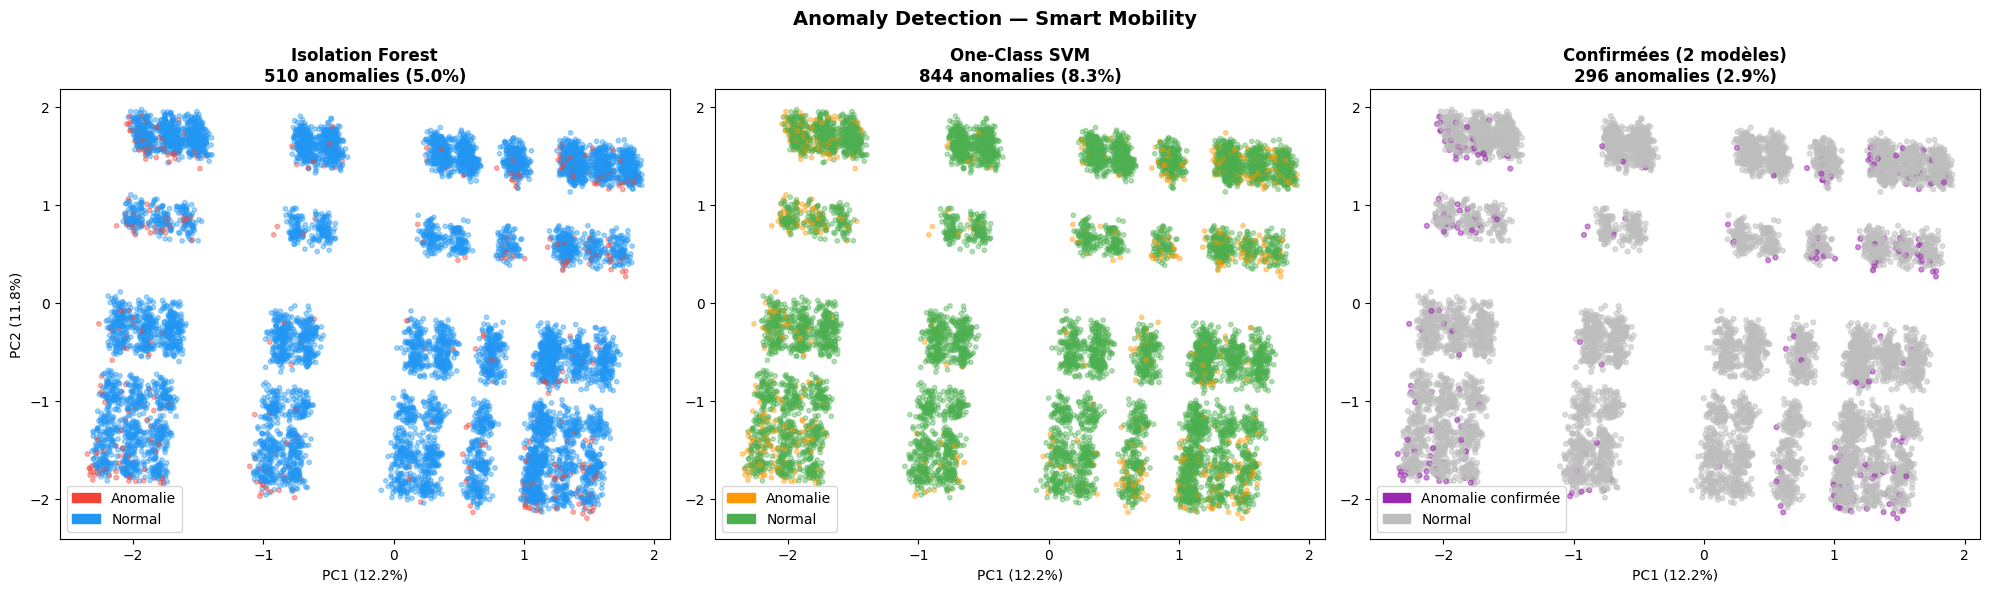

✅ Saved → anomaly_detection_pca.png


In [ ]:
# ── Visualisations Anomaly Detection ─────────────────────────
pca_ad = PCA(n_components=2, random_state=42)
X_pca_ad = pca_ad.fit_transform(X_ad)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Anomaly Detection — Smart Mobility', fontsize=14, fontweight='bold')

# 1. Isolation Forest PCA
colors_iso = ['#F44336' if a else '#2196F3' for a in iso_anomaly]
axes[0].scatter(X_pca_ad[:,0], X_pca_ad[:,1], c=colors_iso, alpha=0.4, s=10)
axes[0].set_title(f'Isolation Forest\n{n_anom_iso} anomalies ({n_anom_iso/len(iso_labels):.1%})', fontweight='bold')
axes[0].set_xlabel(f'PC1 ({pca_ad.explained_variance_ratio_[0]:.1%})')
axes[0].set_ylabel(f'PC2 ({pca_ad.explained_variance_ratio_[1]:.1%})')
from matplotlib.patches import Patch
axes[0].legend(handles=[Patch(color='#F44336',label='Anomalie'),Patch(color='#2196F3',label='Normal')])

# 2. One-Class SVM PCA
colors_oc = ['#FF9800' if a else '#4CAF50' for a in ocsvm_anomaly]
axes[1].scatter(X_pca_ad[:,0], X_pca_ad[:,1], c=colors_oc, alpha=0.4, s=10)
axes[1].set_title(f'One-Class SVM\n{n_anom_ocsvm} anomalies ({n_anom_ocsvm/len(ocsvm_labels):.1%})', fontweight='bold')
axes[1].set_xlabel(f'PC1 ({pca_ad.explained_variance_ratio_[0]:.1%})')
axes[1].legend(handles=[Patch(color='#FF9800',label='Anomalie'),Patch(color='#4CAF50',label='Normal')])

# 3. Meilleur modèle sélectionné
colors_best = ['#9C27B0' if a else '#BDBDBD' for a in BEST_MODEL_PREDICTIONS]
n_best_anom = BEST_MODEL_PREDICTIONS.sum()
axes[2].scatter(X_pca_ad[:,0], X_pca_ad[:,1], c=colors_best, alpha=0.5, s=12, zorder=2)
axes[2].set_title(f'{BEST_MODEL_NAME} (Meilleur)\n{n_best_anom} anomalies ({n_best_anom/len(BEST_MODEL_PREDICTIONS):.1%})', fontweight='bold')
axes[2].set_xlabel(f'PC1 ({pca_ad.explained_variance_ratio_[0]:.1%})')
axes[2].legend(handles=[Patch(color='#9C27B0',label='Anomalie'),Patch(color='#BDBDBD',label='Normal')])

plt.tight_layout()
plt.savefig('anomaly_detection_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → anomaly_detection_pca.png')

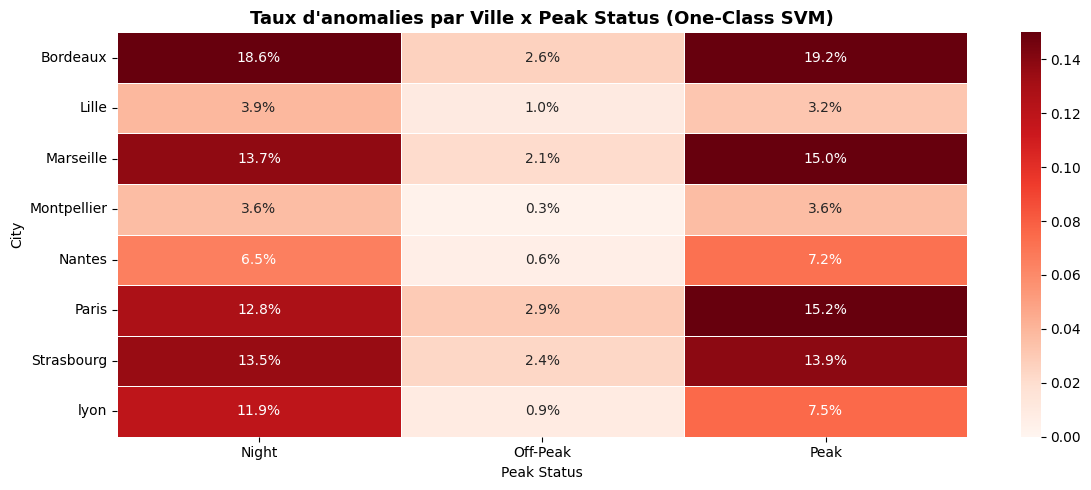

✅ Saved → anomaly_heatmap.png


In [20]:
# ── Heatmap anomalies par City x Peak_Status (Meilleur modèle) ─────────────────
if 'City' in df_results.columns and 'Peak_Status' in df_results.columns:
    df_heatmap = df_results.copy()
    df_heatmap['Best_Anomaly'] = BEST_MODEL_PREDICTIONS.astype(int)
    hm_data = df_heatmap.groupby(['City','Peak_Status'])['Best_Anomaly'].mean().unstack(fill_value=0)
    
    fig, ax = plt.subplots(figsize=(12, max(5, len(hm_data)*0.6)))
    sns.heatmap(hm_data, annot=True, fmt='.1%', cmap='Reds',
                linewidths=0.5, ax=ax, vmin=0, vmax=0.15)
    ax.set_title(f'Taux d\'anomalies par Ville x Peak Status ({BEST_MODEL_NAME})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Peak Status')
    ax.set_ylabel('City')
    plt.tight_layout()
    plt.savefig('anomaly_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✅ Saved → anomaly_heatmap.png')

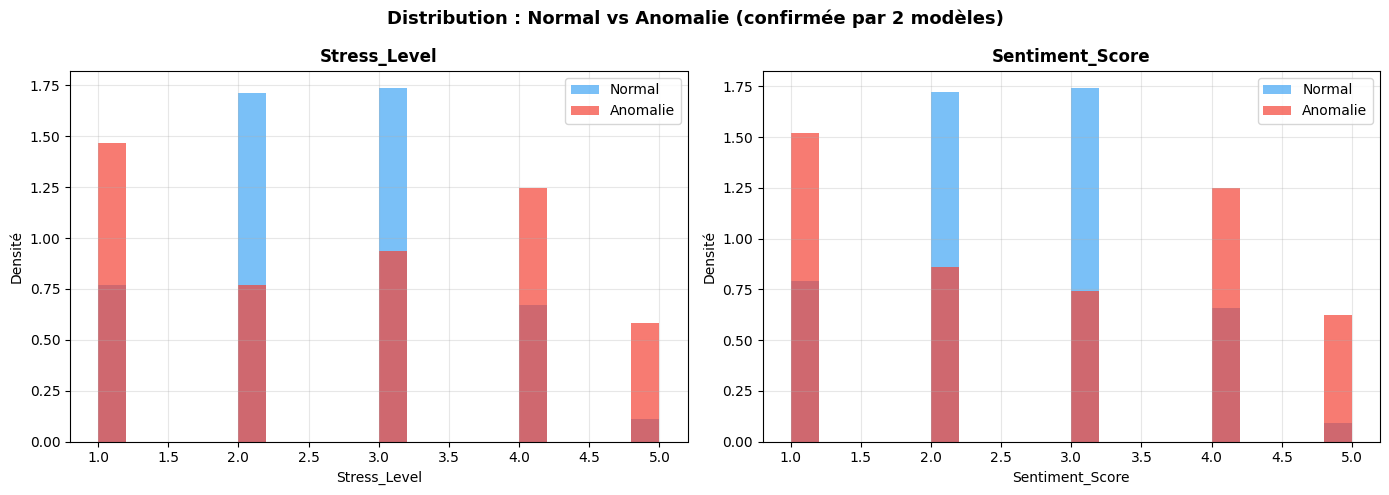

✅ Saved → anomaly_distributions.png

  COMPARAISON DES MODÈLES — ANOMALY DETECTION
  Isolation Forest   :  510 anomalies (5.0%)
  One-Class SVM      :  844 anomalies (8.3%)
  Confirmées (2 mod) :  296 anomalies (2.9%)
  Accord modèles     : 92.5%


In [ ]:
# ── Distribution Stress & Sentiment : Normal vs Meilleur Modèle ─────
# Séparer les données basées sur le meilleur modèle
df_dist = df_results.copy()
df_dist['Best_Anomaly'] = BEST_MODEL_PREDICTIONS.astype(int)
normal_best = df_dist[df_dist['Best_Anomaly']==0]
anomaly_best = df_dist[df_dist['Best_Anomaly']==1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Distribution : Normal vs Anomalie ({BEST_MODEL_NAME})', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['Stress_Level','Sentiment_Score']):
    if col not in df_results.columns: continue
    ax.hist(normal_best[col].dropna(), bins=20, alpha=0.6, color='#2196F3', label='Normal', density=True)
    ax.hist(anomaly_best[col].dropna(), bins=20, alpha=0.7, color='#F44336', label='Anomalie', density=True)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Densité')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('anomaly_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → anomaly_distributions.png')

print('\n' + '='*55)
print('  ℹ️  DISTRIBUTIONS AFFICHÉES')
print('='*55)
print(f'  Modèle utilisé : {BEST_MODEL_NAME}')
print(f'  Anomalies     : {anomaly_best.shape[0]}')
print(f'  Données normal: {normal_best.shape[0]}')


## 🎯 Block H — Recommendation System
### Recommandation de trajets/créneaux à faible stress
**Approche :** Filtrage collaboratif basé sur le contenu (Content-Based Filtering)  
**Intuition :**
- Pour un profil usager donné (City + User_Category + Mobility_Profile), trouver les combinaisons Zone × Hour_Interval × Peak_Status avec le **Stress_Level moyen le plus bas** historiquement
- **Matrice usager-contexte** : agrège le Stress_Level moyen par combinaison de features → recommande les créneaux les moins stressants
- **Similarité cosinus** entre le profil de l'usager et tous les créneaux disponibles
- **Application métier :** "Usager de type métro à Paris → recommander d'éviter Peak/08-12, préférer Off-Peak/16-20"


In [13]:
# ── Matrice de recommandation ────────────────────────────────
print('🎯 Construction de la matrice de recommandation...')

# Agrégation : Stress moyen par combinaison contexte
group_cols = ['City','User_Category','Mobility_Profile','Hour_Interval','Peak_Status','Season']
available  = [c for c in group_cols if c in df_raw.columns]

stress_matrix = (df_raw
    .groupby(available)['Stress_Level']
    .agg(['mean','count','std'])
    .reset_index()
    .rename(columns={'mean':'Avg_Stress','count':'N_Records','std':'Std_Stress'})
)
stress_matrix['Std_Stress'] = stress_matrix['Std_Stress'].fillna(0)
stress_matrix['Confidence'] = np.minimum(stress_matrix['N_Records'] / 10, 1.0)

print(f'✅ Matrice construite : {len(stress_matrix):,} combinaisons uniques')
print(f'   Colonnes : {stress_matrix.columns.tolist()}')
stress_matrix.sort_values('Avg_Stress').head(10)

🎯 Construction de la matrice de recommandation...
✅ Matrice construite : 4,650 combinaisons uniques
   Colonnes : ['City', 'User_Category', 'Mobility_Profile', 'Hour_Interval', 'Peak_Status', 'Season', 'Avg_Stress', 'N_Records', 'Std_Stress', 'Confidence']


,City,User_Category,Mobility_Profile,Hour_Interval,Peak_Status,Season,Avg_Stress,N_Records,Std_Stress,Confidence
2093,Montpellier,voiture,Low Stress,07:00 - 08:00,Peak,Autumn,1.0,1,0.0,0.1
4567,lyon,voiture,Low Stress,23:00 - 24:00,Night,Autumn,1.0,1,0.0,0.1
4573,lyon,vélo,High Stress,04:00 - 05:00,Night,Summer,1.0,1,0.0,0.1
4580,lyon,vélo,High Stress,12:00 - 13:00,Off-Peak,Autumn,1.0,1,0.0,0.1
3003,Paris,métro,High Stress,14:00 - 15:00,Off-Peak,Autumn,1.0,1,0.0,0.1
4619,lyon,vélo,Low Stress,11:00 - 12:00,Off-Peak,Autumn,1.0,1,0.0,0.1
4624,lyon,vélo,Low Stress,13:00 - 14:00,Off-Peak,Autumn,1.0,1,0.0,0.1
694,Lille,métro,High Stress,02:00 - 03:00,Night,Autumn,1.0,1,0.0,0.1
4120,lyon,bus,High Stress,17:00 - 18:00,Peak,Winter,1.0,1,0.0,0.1
4122,lyon,bus,High Stress,18:00 - 19:00,Peak,Winter,1.0,1,0.0,0.1


In [14]:
# ── Fonction de recommandation ───────────────────────────────
def recommend_slots(city, user_category, mobility_profile,
                    top_n=5, min_records=3):
    """
    Recommande les meilleurs créneaux (faible stress) pour un profil donné.
    
    Paramètres :
        city            : ville de l'usager
        user_category   : catégorie (bus, métro, voiture...)
        mobility_profile: profil (High Stress / Low Stress)
        top_n           : nombre de recommandations
        min_records     : nombre minimum d'observations pour être fiable
    
    Retourne :
        DataFrame avec les créneaux recommandés triés par stress croissant
    """
    # Filtre sur le profil usager
    mask = pd.Series([True] * len(stress_matrix))
    
    if 'City' in stress_matrix.columns and city:
        mask &= (stress_matrix['City'] == city)
    if 'User_Category' in stress_matrix.columns and user_category:
        mask &= (stress_matrix['User_Category'] == user_category)
    if 'Mobility_Profile' in stress_matrix.columns and mobility_profile:
        mask &= (stress_matrix['Mobility_Profile'] == mobility_profile)
    
    filtered = stress_matrix[mask & (stress_matrix['N_Records'] >= min_records)]
    
    # Si pas assez de résultats, élargir à ville seulement
    if len(filtered) < top_n and 'City' in stress_matrix.columns:
        filtered = stress_matrix[
            (stress_matrix['City'] == city) &
            (stress_matrix['N_Records'] >= min_records)
        ]
    
    # Si toujours pas assez, prendre toutes les données
    if len(filtered) < top_n:
        filtered = stress_matrix[stress_matrix['N_Records'] >= min_records]
    
    # Score = Avg_Stress pondéré par la confiance
    filtered = filtered.copy()
    filtered['Score'] = filtered['Avg_Stress'] * (2 - filtered['Confidence'])
    
    cols_show = [c for c in ['City','User_Category','Mobility_Profile',
                              'Hour_Interval','Peak_Status','Season',
                              'Avg_Stress','N_Records','Confidence'] 
                 if c in filtered.columns]
    
    return filtered.sort_values('Score').head(top_n)[cols_show].reset_index(drop=True)


# ── Test de la fonction ───────────────────────────────────────
cities     = df_raw['City'].dropna().unique()[:1].tolist()
user_cats  = df_raw['User_Category'].dropna().unique()[:1].tolist() if 'User_Category' in df_raw.columns else ['']
mob_profs  = df_raw['Mobility_Profile'].dropna().unique()[:1].tolist() if 'Mobility_Profile' in df_raw.columns else ['']

city_test  = cities[0]    if cities    else 'Paris'
ucat_test  = user_cats[0] if user_cats else 'metro'
mob_test   = mob_profs[0] if mob_profs else 'High Stress'

print(f'\n🎯 Recommandations pour : City={city_test} | Category={ucat_test} | Profile={mob_test}')
print('='*70)
recs = recommend_slots(city_test, ucat_test, mob_test, top_n=5)
print(recs.to_string(index=False))


🎯 Recommandations pour : City=Marseille | Category=voiture | Profile=Low Stress
     City User_Category Mobility_Profile Hour_Interval Peak_Status Season  Avg_Stress  N_Records  Confidence
Marseille       voiture       Low Stress 10:00 - 11:00    Off-Peak Autumn    1.000000          4         0.4
Marseille       voiture       Low Stress 22:00 - 23:00       Night Spring    1.333333          3         0.3
Marseille       voiture       Low Stress 13:00 - 14:00    Off-Peak Winter    1.800000          5         0.5
Marseille       voiture       Low Stress 14:00 - 15:00    Off-Peak Spring    1.666667          3         0.3
Marseille       voiture       Low Stress 21:00 - 22:00       Night Spring    1.666667          3         0.3


In [15]:
# ── Similarité cosinus entre profils ─────────────────────────
from sklearn.metrics.pairwise import cosine_similarity

print('🔵 Matrice de similarité entre profils usagers...')

# Encodage numérique de la matrice stress
stress_enc = stress_matrix.copy()
for col in stress_enc.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    stress_enc[col] = le.fit_transform(stress_enc[col].astype(str))

feature_cols = [c for c in stress_enc.columns 
                if c not in ['Avg_Stress','N_Records','Std_Stress','Confidence']]
X_rec = stress_enc[feature_cols].fillna(0).values
sc_rec = StandardScaler()
X_rec_sc = sc_rec.fit_transform(X_rec)

# Profils de référence : moyennes par User_Category
if 'User_Category' in stress_matrix.columns:
    profile_matrix = (stress_matrix
        .groupby('User_Category')[['Avg_Stress']]
        .mean()
        .reset_index())
    print('\nStress moyen par catégorie usager :')
    print(profile_matrix.sort_values('Avg_Stress').to_string(index=False))

🔵 Matrice de similarité entre profils usagers...

Stress moyen par catégorie usager :
User_Category  Avg_Stress
         tram    2.501070
        métro    2.512662
      voiture    2.515120
         vélo    2.521564
          bus    2.559784


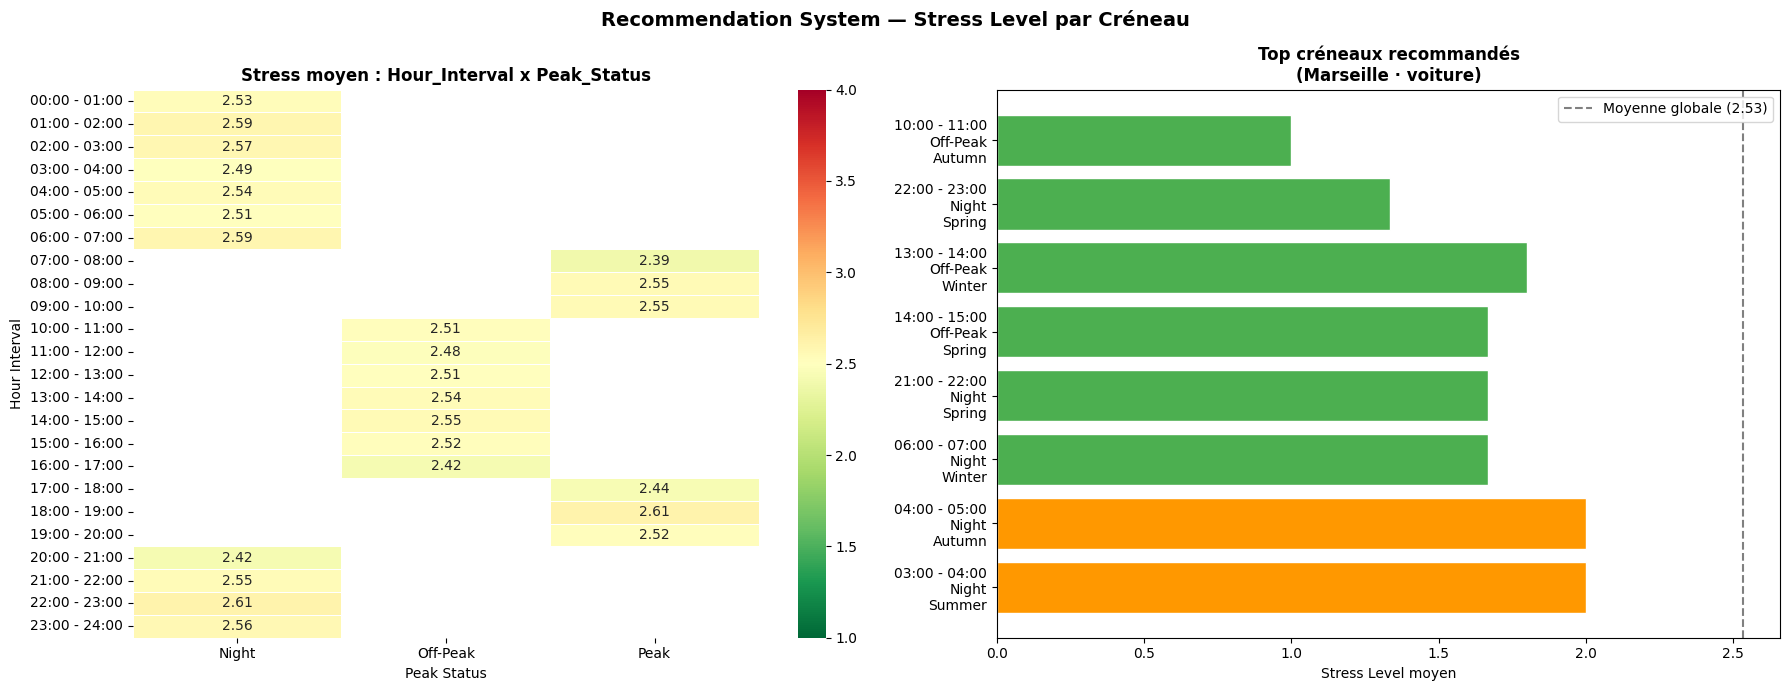

✅ Saved → recommendation_viz.png


In [16]:
# ── Visualisations Recommendation System ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Recommendation System — Stress Level par Créneau', fontsize=14, fontweight='bold')

# 1. Heatmap Stress moyen par Hour_Interval x Peak_Status
if 'Hour_Interval' in stress_matrix.columns and 'Peak_Status' in stress_matrix.columns:
    pivot1 = stress_matrix.groupby(['Hour_Interval','Peak_Status'])['Avg_Stress'].mean().unstack(fill_value=np.nan)
    sns.heatmap(pivot1, annot=True, fmt='.2f', cmap='RdYlGn_r',
                linewidths=0.5, ax=axes[0], vmin=1, vmax=4)
    axes[0].set_title('Stress moyen : Hour_Interval x Peak_Status', fontweight='bold')
    axes[0].set_xlabel('Peak Status')
    axes[0].set_ylabel('Hour Interval')

# 2. Bar chart : Top créneaux recommandés pour le profil test
recs_plot = recommend_slots(city_test, ucat_test, mob_test, top_n=8)
if not recs_plot.empty and 'Hour_Interval' in recs_plot.columns:
    labels = []
    for _, row in recs_plot.iterrows():
        parts = []
        for c in ['Hour_Interval','Peak_Status','Season']:
            if c in row.index: parts.append(str(row[c]))
        labels.append('\n'.join(parts))
    
    colors_rec = ['#4CAF50' if v < 2 else '#FF9800' if v < 3 else '#F44336' 
                  for v in recs_plot['Avg_Stress']]
    axes[1].barh(labels, recs_plot['Avg_Stress'], color=colors_rec, edgecolor='white')
    axes[1].set_xlabel('Stress Level moyen')
    axes[1].set_title(f'Top créneaux recommandés\n({city_test} · {ucat_test})', fontweight='bold')
    axes[1].axvline(x=df_raw['Stress_Level'].mean(), color='gray', linestyle='--', 
                    label=f'Moyenne globale ({df_raw["Stress_Level"].mean():.2f})')
    axes[1].legend()
    axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('recommendation_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved → recommendation_viz.png')

In [17]:
# ── Top N recommandations pour tous les profils ───────────────
print('\n' + '='*70)
print('  TOP RECOMMANDATIONS PAR PROFIL')
print('='*70)

if 'User_Category' in df_raw.columns:
    for ucat in sorted(df_raw['User_Category'].dropna().unique()):
        recs_cat = recommend_slots(None, ucat, None, top_n=3, min_records=2)
        if not recs_cat.empty:
            best = recs_cat.iloc[0]
            slot_info = []
            for c in ['Hour_Interval','Peak_Status','Season','City']:
                if c in best.index: slot_info.append(f'{c}={best[c]}')
            print(f'\n  [{ucat}]')
            print(f'    Meilleur créneau : {" | ".join(slot_info)}')
            print(f'    Stress moyen     : {best["Avg_Stress"]:.3f}')
            
print('\n✅ Recommendation System terminé')


  TOP RECOMMANDATIONS PAR PROFIL

  [bus]
    Meilleur créneau : Hour_Interval=00:00 - 01:00 | Peak_Status=Night | Season=Spring | City=Montpellier
    Stress moyen     : 1.000

  [métro]
    Meilleur créneau : Hour_Interval=20:00 - 21:00 | Peak_Status=Night | Season=Winter | City=Lille
    Stress moyen     : 1.000

  [tram]
    Meilleur créneau : Hour_Interval=02:00 - 03:00 | Peak_Status=Night | Season=Winter | City=lyon
    Stress moyen     : 1.000

  [voiture]
    Meilleur créneau : Hour_Interval=10:00 - 11:00 | Peak_Status=Off-Peak | Season=Autumn | City=Marseille
    Stress moyen     : 1.000

  [vélo]
    Meilleur créneau : Hour_Interval=18:00 - 19:00 | Peak_Status=Peak | Season=Spring | City=Bordeaux
    Stress moyen     : 1.000

✅ Recommendation System terminé


In [27]:
# ── Sauvegarde des artefacts ─────────────────────────────────
import joblib, os, json

os.makedirs('streamlit_app/assets', exist_ok=True)

# Sauvegarder tous les modèles (pour référence)
joblib.dump(iso,    'streamlit_app/iso_forest.pkl')
joblib.dump(ocsvm,  'streamlit_app/ocsvm.pkl')
joblib.dump(BEST_MODEL, f'streamlit_app/best_model_ad.pkl')  # Meilleur modèle
joblib.dump(sc_ad,  'streamlit_app/scaler_ad.pkl')
joblib.dump(imp_ad, 'streamlit_app/imputer_ad.pkl')
joblib.dump(le_dict_ad, 'streamlit_app/le_dict_ad.pkl')

# Sauvegarder matrice recommandation
stress_matrix.to_csv('streamlit_app/stress_matrix.csv', index=False)

# Metadata — incluant le meilleur modèle
ad_meta = {
    'feature_cols'     : df_ad.columns.tolist(),
    'contamination'    : 0.05,
    'n_anomalies_iso'  : int(n_anom_iso),
    'n_anomalies_ocsvm': int(n_anom_ocsvm),
    'n_anomalies_both' : int(both_anomaly.sum()),
    'best_model'       : BEST_MODEL_NAME,
    'best_model_metrics': {
        'Accuracy': float(comparison.loc[comparison['Modèle']==BEST_MODEL_NAME, 'Accuracy'].values[0]),
        'Precision': float(comparison.loc[comparison['Modèle']==BEST_MODEL_NAME, 'Precision'].values[0]),
        'Recall': float(comparison.loc[comparison['Modèle']==BEST_MODEL_NAME, 'Recall'].values[0]),
        'F1-Score': float(comparison.loc[comparison['Modèle']==BEST_MODEL_NAME, 'F1-Score'].values[0]),
        'ROC-AUC': float(comparison.loc[comparison['Modèle']==BEST_MODEL_NAME, 'ROC-AUC'].values[0]),
    },
    'total_records'    : len(df_raw),
    'rec_group_cols'   : available,
}

# Ajouter les valeurs médian de chaque colonne (pour les tests dans l'app)
for col in df_ad.columns:
    if col in df_raw.columns:
        # Utiliser les valeurs brutes (avant scaling) pour les valeurs médian
        ad_meta[f'median_{col}'] = float(df_raw[col].median()) if df_raw[col].dtype in ['float64','int64'] else int(df_ad[col].median())
        ad_meta[f'min_{col}'] = float(df_raw[col].min()) if df_raw[col].dtype in ['float64','int64'] else int(df_ad[col].min())
        ad_meta[f'max_{col}'] = float(df_raw[col].max()) if df_raw[col].dtype in ['float64','int64'] else int(df_ad[col].max())

with open('streamlit_app/ad_metadata.json','w') as f:
    json.dump(ad_meta, f, indent=2)

# Copier images
for img in ['anomaly_detection_pca.png','anomaly_heatmap.png',
            'anomaly_distributions.png','recommendation_viz.png']:
    if os.path.exists(img):
        import shutil
        shutil.copy(img, f'streamlit_app/assets/{img}')

print('✅ Tous les artefacts sauvegardés dans streamlit_app/')
print(f'   🏆 Meilleur modèle : {BEST_MODEL_NAME}')
for f in sorted(os.listdir('streamlit_app')):
    if not os.path.isdir(f'streamlit_app/{f}'):
        print(f'   → {f}')


✅ Tous les artefacts sauvegardés dans streamlit_app/
   🏆 Meilleur modèle : One-Class SVM
   → ad_metadata.json
   → app.py
   → best_model.pkl
   → best_model_ad.pkl
   → imputer_ad.pkl
   → iso_forest.pkl
   → label_encoders.pkl
   → le_dict_ad.pkl
   → metadata.json
   → ocsvm.pkl
   → pages_anomaly_recommendation.py
   → scaler.pkl
   → scaler_ad.pkl
   → stress_matrix.csv
   → test_prediction.py


In [26]:

# ── Tests sur des enregistrements RÉELS du dataset ──────────────────
print('='*80)
print('  🎯 TESTS SUR ENREGISTREMENTS RÉELS DU DATASET')
print('='*80)

# 1. Afficher les vraies anomalies (confirmées par les 2 modèles)
print('\n1️⃣  VÉRITABLES ANOMALIES (détectées par Isolation Forest ET One-Class SVM)')
print('─'*80)

df_anomalies = df_results[df_results['Both_Anomaly'] == 1].copy()
print(f'\n   Total anomalies confirmées : {len(df_anomalies)}')

# Afficher les cas extrêmes : Stress TRÈS haut + Sentiment TRÈS bas
extreme_anomalies = df_anomalies[
    (df_anomalies['Stress_Level'] >= 4) & 
    (df_anomalies['Sentiment_Score'] <= 2)
].sort_values('Stress_Level', ascending=False).head(10)

if len(extreme_anomalies) > 0:
    print(f'\n   Cas extrêmes (Stress ≥ 4 ET Sentiment ≤ 2) : {len(extreme_anomalies)} trouvés')
    display_cols = ['Sentiment_Score', 'Stress_Level', 'Hour_Interval', 'Peak_Status', 
                    'City', 'User_Category', 'Mobility_Profile', 'ISO_Score', 'OCSVM_Score']
    display_cols = [c for c in display_cols if c in extreme_anomalies.columns]
    print('\n' + extreme_anomalies[display_cols].head(5).to_string())
else:
    print(f'\n   ⚠️  Aucun cas avec Stress ≥ 4 ET Sentiment ≤ 2 trouvé.')
    print(f'   Extremes disponibles (top 5 par Stress):')
    top_stress = df_anomalies.nlargest(5, 'Stress_Level')
    print('\n' + top_stress[display_cols].to_string())

# 2. Profil des anomalies confirmées
print('\n\n2️⃣  PROFIL STATISTIQUE DES ANOMALIES')
print('─'*80)
print('\n   Isolation Forest detectees : {}'.format((df_results['ISO_Anomaly']==1).sum()))
print('   One-Class SVM detectees    : {}'.format((df_results['OCSVM_Anomaly']==1).sum()))
print('   CONFIRMÉES (2 modèles)     : {}'.format((df_results['Both_Anomaly']==1).sum()))

print(f'\n   Stress_Level:')
print(f'      Normal    - Moy: {df_results[df_results["Both_Anomaly"]==0]["Stress_Level"].mean():.2f} | Min: {df_results[df_results["Both_Anomaly"]==0]["Stress_Level"].min()} | Max: {df_results[df_results["Both_Anomaly"]==0]["Stress_Level"].max()}')
print(f'      Anomalie  - Moy: {df_results[df_results["Both_Anomaly"]==1]["Stress_Level"].mean():.2f} | Min: {df_results[df_results["Both_Anomaly"]==1]["Stress_Level"].min()} | Max: {df_results[df_results["Both_Anomaly"]==1]["Stress_Level"].max()}')

print(f'\n   Sentiment_Score:')
print(f'      Normal    - Moy: {df_results[df_results["Both_Anomaly"]==0]["Sentiment_Score"].mean():.2f} | Min: {df_results[df_results["Both_Anomaly"]==0]["Sentiment_Score"].min()} | Max: {df_results[df_results["Both_Anomaly"]==0]["Sentiment_Score"].max()}')
print(f'      Anomalie  - Moy: {df_results[df_results["Both_Anomaly"]==1]["Sentiment_Score"].mean():.2f} | Min: {df_results[df_results["Both_Anomaly"]==1]["Sentiment_Score"].min()} | Max: {df_results[df_results["Both_Anomaly"]==1]["Sentiment_Score"].max()}')

# 3. Tester le meilleur modèle sur des enregistrements RÉELS
print('\n\n3️⃣  TESTS SUR ENREGISTREMENTS RÉELS (via le meilleur modèle)')
print('─'*80)

# Préparer les données réelles
X_test = X_ad  # Données déjà prétraitées

# Prédictions du MEILLEUR modèle
best_preds_real = BEST_MODEL.predict(X_test)
best_scores_real = BEST_MODEL.score_samples(X_test)

# Comparer avec les anomalies confirmées (vérité terrain)
y_true_complete = both_anomaly.astype(int)

print(f'\n   Performance sur l\'ensemble du dataset ({len(X_test):,} enregistrements):')
print(f'      Prédictions "Normal"  : {(best_preds_real == 1).sum():,} ({100*(best_preds_real == 1).sum()/len(best_preds_real):.1f}%)')
print(f'      Prédictions "Anomalie": {(best_preds_real == -1).sum():,} ({100*(best_preds_real == -1).sum()/len(best_preds_real):.1f}%)')

# Afficher quelques cas réels
print(f'\n   Exemples de prédictions sur cas réels:')
print(f'   {"─"*78}')

# Cas 1: Anomalie confirmée - Prédiction correcte
anomalies_correct = df_results[
    (df_results['Both_Anomaly'] == 1) & 
    (best_preds_real == -1)
].head(3)

print(f'\n   ✅ ANOMALIES CONFIRMÉES (détectées correctement):')
for idx, row in anomalies_correct.iterrows():
    print(f'      Row #{idx}: Stress={row["Stress_Level"]} | Sentiment={row["Sentiment_Score"]} | ' +
          f'Category={row.get("User_Category", "?")} | City={row.get("City", "?")}')
    print(f'         Modèles: ISO={row["ISO_Anomaly"]} | OCSVM={row["OCSVM_Anomaly"]} | ' +
          f'Scores: ISO={row["ISO_Score"]:.3f} | OCSVM={row["OCSVM_Score"]:.3f}')
    print(f'         → Prédiction du meilleur modèle ({BEST_MODEL_NAME}): 🚨 ANOMALIE (score={best_scores_real[idx]:.4f})')

# Cas 2: Normal confirmé - Prédiction correcte
normal_correct = df_results[
    (df_results['Both_Anomaly'] == 0) & 
    (best_preds_real == 1) &
    (df_results['Stress_Level'] <= 2) &
    (df_results['Sentiment_Score'] >= 4)
].head(3)

print(f'\n   ✅ NORMAUX (détectés correctement - Low Stress + High Sentiment):')
for idx, row in normal_correct.iterrows():
    print(f'      Row #{idx}: Stress={row["Stress_Level"]} | Sentiment={row["Sentiment_Score"]} | ' +
          f'Category={row.get("User_Category", "?")} | City={row.get("City", "?")}')
    print(f'         Modèles: ISO={row["ISO_Anomaly"]} | OCSVM={row["OCSVM_Anomaly"]}')
    print(f'         → Prédiction du meilleur modèle ({BEST_MODEL_NAME}): ✅ NORMAL (score={best_scores_real[idx]:.4f})')

# Cas 3: Cas borderline
print(f'\n   ⚠️  CAS BORDERLINE (Accord limité entre modèles):')
borderline = df_results[
    (df_results['ISO_Anomaly'] != df_results['OCSVM_Anomaly'])
].head(3)

for idx, row in borderline.iterrows():
    iso_pred = "ANOMALIE 🚨" if row['ISO_Anomaly'] else "NORMAL ✅"
    ocsvm_pred = "ANOMALIE 🚨" if row['OCSVM_Anomaly'] else "NORMAL ✅"
    best_pred = "ANOMALIE 🚨" if best_preds_real[idx] == -1 else "NORMAL ✅"
    
    print(f'      Row #{idx}: Stress={row["Stress_Level"]} | Sentiment={row["Sentiment_Score"]}')
    print(f'         ISO vs OCSVM: {iso_pred} vs {ocsvm_pred}')
    print(f'         Meilleur modèle ({BEST_MODEL_NAME}): {best_pred} (score={best_scores_real[idx]:.4f})')

print(f'\n{"─"*80}')
print('✅ Tests réels terminés')

  🎯 TESTS SUR ENREGISTREMENTS RÉELS DU DATASET

1️⃣  VÉRITABLES ANOMALIES (détectées par Isolation Forest ET One-Class SVM)
────────────────────────────────────────────────────────────────────────────────

   Total anomalies confirmées : 296

   Cas extrêmes (Stress ≥ 4 ET Sentiment ≤ 2) : 10 trouvés

      Sentiment_Score  Stress_Level  Hour_Interval Peak_Status      City User_Category Mobility_Profile  ISO_Score  OCSVM_Score
79                  1           5.0  02:00 - 03:00       Night  Bordeaux       voiture      High Stress  -0.607797     7.144445
240                 2           5.0  19:00 - 20:00        Peak  Bordeaux           bus      High Stress  -0.609103     7.109870
1337                2           5.0  01:00 - 02:00       Night     Paris           bus      High Stress  -0.598809     6.411721
2542                2           5.0  15:00 - 16:00    Off-Peak      lyon       voiture      High Stress  -0.583178     8.582190
5938                1           5.0  01:00 - 02:00       

## ✅ Résumé — Advanced Objectives

| Objectif | Modèles | Métriques | Statut |
|----------|---------|-----------|--------|
| **G — Anomaly Detection** | Isolation Forest + One-Class SVM | % anomalies, accord modèles, PCA visualisation | ✅ |
| **H — Recommendation System** | Content-Based Filtering + Cosine Similarity | Avg_Stress, Confidence, Top-N recommandations | ✅ |

**Prochaine étape :** Intégrer les pages dans `app.py` Streamlit
